In [10]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn import tree
import optuna
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [11]:
def sklearn_metrick_printer(y_true, y_pred):
    print(f'MAE: {mean_absolute_error(y_true, y_pred)}')
    print(f'MSE: {mean_squared_error(y_true, y_pred)}')
    print(f'RMSE: {math.sqrt(mean_squared_error(y_true, y_pred))}')
    print(f'MAPE: {mean_absolute_percentage_error(y_true, y_pred)}')
    print(f'R^2: {r2_score(y_true, y_pred)}')

In [12]:
data = pd.read_csv('data/r5_eda.csv')

In [13]:
y = data['quality']
X = data.drop('quality', axis=1)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

### DecisionTreeRegressor

In [15]:
reg = DecisionTreeRegressor(max_depth=6)
reg.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=6)

In [16]:
y_pred = reg.predict(X_test)
sklearn_metrick_printer(y_test, y_pred)

MAE: 0.5713188957136801
MSE: 0.5598031816524632
RMSE: 0.7481999610080605
MAPE: 0.10127576835750553
R^2: 0.27799800128618424


#### Подбор гиперпараметров

In [17]:
def objective(trial):
    max_depth = trial.suggest_int('max_depth', 1, 32)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 20)
    max_features = trial.suggest_categorical('max_features', [None, 'sqrt', 'log2'])
    
    model = DecisionTreeRegressor(
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=42
    )
    
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
    return -scores.mean()

# study = optuna.create_study(direction='minimize')
# study.optimize(objective, n_trials=50)

In [18]:
# reg = DecisionTreeRegressor(**study.best_params, random_state=42)
reg = DecisionTreeRegressor(max_depth=7, min_samples_leaf=17, min_samples_split=6,
                      random_state=42)
reg.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=7, min_samples_leaf=17, min_samples_split=6,
                      random_state=42)

In [19]:
y_pred = reg.predict(X_test)
sklearn_metrick_printer(y_test, y_pred)

MAE: 0.5644318186548791
MSE: 0.5392560684285899
RMSE: 0.7343405670590383
MAPE: 0.09955634984796671
R^2: 0.3044984880673499


### BaggingRegressor

In [20]:
base_regressor = DecisionTreeRegressor(max_depth=6)

bg_reg = BaggingRegressor(
    estimator=base_regressor,
    n_estimators=100,
    random_state=42
)

bg_reg.fit(X_train, y_train)

BaggingRegressor(estimator=DecisionTreeRegressor(max_depth=6), n_estimators=100,
                 random_state=42)

In [21]:
y_pred = bg_reg.predict(X_test)
sklearn_metrick_printer(y_test, y_pred)

MAE: 0.5481585730829021
MSE: 0.49158650211832816
RMSE: 0.7011323000107242
MAPE: 0.09717727707191658
R^2: 0.3659799574156196


#### Подбор гиперпараметров

In [22]:
def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 10, 200)
    max_samples = trial.suggest_float('max_samples', 0.1, 1.0)
    max_features = trial.suggest_float('max_features', 0.1, 1.0)
    bootstrap = trial.suggest_categorical('bootstrap', [True, False])
    
    model = BaggingRegressor(
        n_estimators=n_estimators,
        max_samples=max_samples,
        max_features=max_features,
        bootstrap=bootstrap,
        random_state=42
    )
    
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
    return -scores.mean()

# study = optuna.create_study(direction='minimize')
# study.optimize(objective, n_trials=50)

In [23]:
# bg_reg = BaggingRegressor(**study.best_params, random_state=42)
bg_reg = BaggingRegressor(bootstrap=False, max_features=0.8155447145017635,
                 max_samples=0.824318215106522, n_estimators=193,
                 random_state=42)
bg_reg.fit(X_train, y_train)

BaggingRegressor(bootstrap=False, max_features=0.8155447145017635,
                 max_samples=0.824318215106522, n_estimators=193,
                 random_state=42)

In [24]:
y_pred = bg_reg.predict(X_test)
sklearn_metrick_printer(y_test, y_pred)

MAE: 0.4082742128337984
MSE: 0.3576661841205856
RMSE: 0.5980519911517607
MAPE: 0.07321840105777931
R^2: 0.5387026936054032


### GradientBoostingRegressor

In [25]:
gb_reg = GradientBoostingRegressor(max_depth=6, n_estimators=100, random_state=42)
gb_reg.fit(X_train, y_train)

GradientBoostingRegressor(max_depth=6, random_state=42)

In [26]:
y_pred = gb_reg.predict(X_test)
sklearn_metrick_printer(y_test, y_pred)

MAE: 0.4889459337198262
MSE: 0.41358136094206077
RMSE: 0.6431029162910559
MAPE: 0.08704984779089303
R^2: 0.4665865092986756


#### Подбор гиперпараметров

In [27]:
def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3)
    max_depth = trial.suggest_int('max_depth', 1, 10)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 20)
    subsample = trial.suggest_float('subsample', 0.5, 1.0)
    
    model = GradientBoostingRegressor(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        subsample=subsample,
        random_state=42
    )
    
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
    return -scores.mean()

# study = optuna.create_study(direction='minimize')
# study.optimize(objective, n_trials=50)

In [28]:
# gb_reg = GradientBoostingRegressor(**study.best_params, random_state=42)
gb_reg = GradientBoostingRegressor(learning_rate=0.07702481201263307, max_depth=10,
                          min_samples_leaf=4, min_samples_split=18,
                          n_estimators=199, random_state=42,
                          subsample=0.656550698796666)
gb_reg.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.07702481201263307, max_depth=10,
                          min_samples_leaf=4, min_samples_split=18,
                          n_estimators=199, random_state=42,
                          subsample=0.656550698796666)

In [29]:
y_pred = gb_reg.predict(X_test)
sklearn_metrick_printer(y_test, y_pred)

MAE: 0.42299369362729694
MSE: 0.3728454640978045
RMSE: 0.6106107304148892
MAPE: 0.07560266424603132
R^2: 0.5191253299144043


### StackingRegressor

In [30]:
estimators = [
    ('dt', DecisionTreeRegressor(max_depth=3)),
    ('lr', LinearRegression())
]

stack_reg = StackingRegressor(estimators=estimators, final_estimator=LinearRegression())
stack_reg.fit(X_train, y_train)

StackingRegressor(estimators=[('dt', DecisionTreeRegressor(max_depth=3)),
                              ('lr', LinearRegression())],
                  final_estimator=LinearRegression())

In [31]:
y_pred = stack_reg.predict(X_test)
sklearn_metrick_printer(y_test, y_pred)

MAE: 0.5717580656166578
MSE: 0.5411773804856674
RMSE: 0.7356475925914986
MAPE: 0.1011465886652592
R^2: 0.30202049010158605


#### Подбор гиперпараметров

In [32]:
def objective(trial):
    dt_max_depth = trial.suggest_int('dt_max_depth', 1, 10)
    dt_min_samples_split = trial.suggest_int('dt_min_samples_split', 2, 20)
    alpha = trial.suggest_float('alpha', 0.1, 10.0)
    
    estimators = [
        ('dt', DecisionTreeRegressor(max_depth=dt_max_depth, min_samples_split=dt_min_samples_split, random_state=42)),
        ('lr', LinearRegression())
    ]
    meta_model = Ridge(alpha=alpha, random_state=42)
    
    model = StackingRegressor(estimators=estimators, final_estimator=meta_model)
    
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
    return -scores.mean()

# study = optuna.create_study(direction='minimize')
# study.optimize(objective, n_trials=50)

In [33]:
# best_params = study.best_params
best_estimators = [
    # ('dt', DecisionTreeRegressor(
    #     max_depth=best_params['dt_max_depth'], min_samples_split=best_params['dt_min_samples_split'], random_state=42)),
    ('dt', DecisionTreeRegressor(max_depth=10, min_samples_split=15, random_state=42)),
    ('lr', LinearRegression())
]
# best_meta_model = Ridge(alpha=best_params['alpha'], random_state=42)
best_meta_model = Ridge(alpha=9.494307568806033, random_state=42)
stack_reg = StackingRegressor(
    estimators=best_estimators, final_estimator=best_meta_model)
stack_reg.fit(X_train, y_train)

StackingRegressor(estimators=[('dt',
                               DecisionTreeRegressor(max_depth=10,
                                                     min_samples_split=15,
                                                     random_state=42)),
                              ('lr', LinearRegression())],
                  final_estimator=Ridge(alpha=9.494307568806033,
                                        random_state=42))

In [34]:
y_pred = stack_reg.predict(X_test)
sklearn_metrick_printer(y_test, y_pred)

MAE: 0.545545967112112
MSE: 0.5045239907311607
RMSE: 0.71029852226452
MAPE: 0.09674114988805671
R^2: 0.3492939274984095


### CatBoostRegressor

In [35]:
cat_model = CatBoostRegressor(
    max_depth=3,
    n_estimators=100,
    learning_rate=0.1,
    random_seed=42,
    verbose=0
)
cat_model.fit(X_train, y_train)

In [36]:
y_pred = cat_model.predict(X_test)
sklearn_metrick_printer(y_test, y_pred)

MAE: 0.5508170591489875
MSE: 0.48920994729574385
RMSE: 0.6994354489842103
MAPE: 0.09714205019121673
R^2: 0.3690451013594138


#### Подбор гиперпараметров

In [37]:
def objective(trial):
    iterations = trial.suggest_int('iterations', 50, 300)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3)
    depth = trial.suggest_int('depth', 1, 10)
    l2_leaf_reg = trial.suggest_float('l2_leaf_reg', 1, 10)
    bagging_temperature = trial.suggest_float('bagging_temperature', 0, 1)
    
    model = CatBoostRegressor(
        iterations=iterations,
        learning_rate=learning_rate,
        depth=depth,
        l2_leaf_reg=l2_leaf_reg,
        bagging_temperature=bagging_temperature,
        random_seed=42,
        verbose=0
    )
    
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
    return -scores.mean()

# study = optuna.create_study(direction='minimize')
# study.optimize(objective, n_trials=50)

In [38]:
# cat_model = CatBoostRegressor(**study.best_params, random_seed=42, verbose=0)
cat_model = CatBoostRegressor(iterations=239, learning_rate=0.1735670585336696, depth=10,
                              l2_leaf_reg=1.5575204985618745, bagging_temperature=0.9612943749961429, random_seed=42, verbose=0)
cat_model.fit(X_train, y_train)

In [39]:
y_pred = cat_model.predict(X_test)
sklearn_metrick_printer(y_test, y_pred)

MAE: 0.4302954543211205
MSE: 0.3679126497157093
RMSE: 0.6065580349115073
MAPE: 0.07685210031757019
R^2: 0.5254873906526871


### XGBRegressor

In [40]:
xgb_model = XGBRegressor(
    max_depth=3,
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    verbosity=0
)
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [41]:
y_pred = xgb_model.predict(X_test)
sklearn_metrick_printer(y_test, y_pred)

MAE: 0.5367926412362318
MSE: 0.46876537193965445
RMSE: 0.6846644228668921
MAPE: 0.09472017443733192
R^2: 0.3954133406866346


#### Подбор гиперпараметров

In [42]:
def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    max_depth = trial.suggest_int('max_depth', 1, 10)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3)
    subsample = trial.suggest_float('subsample', 0.5, 1.0)
    colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0)
    gamma = trial.suggest_float('gamma', 0, 5)
    reg_alpha = trial.suggest_float('reg_alpha', 0, 10)
    reg_lambda = trial.suggest_float('reg_lambda', 0, 10)
    
    model = XGBRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        gamma=gamma,
        reg_alpha=reg_alpha,
        reg_lambda=reg_lambda,
        random_state=42,
        verbosity=0
    )
    
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
    return -scores.mean()

# study = optuna.create_study(direction='minimize')
# study.optimize(objective, n_trials=50)

In [44]:
# xgb_model = XGBRegressor(**study.best_params, random_state=42, verbosity=0)
XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8721386921131723, device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, feature_weights=None,
             gamma=0.01172749841706952, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.16879509767187384,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=9, max_leaves=None,
             min_child_weight=None, monotone_constraints=None,
             multi_strategy=None, n_estimators=113, n_jobs=None,
             num_parallel_tree=None)
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [45]:
y_pred = xgb_model.predict(X_test)
sklearn_metrick_printer(y_test, y_pred)

MAE: 0.5367926412362318
MSE: 0.46876537193965445
RMSE: 0.6846644228668921
MAPE: 0.09472017443733192
R^2: 0.3954133406866346


### LGBMRegressor

In [46]:
lgb_model = LGBMRegressor(
    max_depth=3,
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    verbose=-1
)
lgb_model.fit(X_train, y_train)

LGBMRegressor(max_depth=3, random_state=42, verbose=-1)

In [ ]:
y_pred = lgb_model.predict(X_test)
sklearn_metrick_printer(y_test, y_pred)

#### Подбор гиперпараметров

In [48]:
def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    max_depth = trial.suggest_int('max_depth', 1, 10)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3)
    num_leaves = trial.suggest_int('num_leaves', 2, 100)
    min_child_samples = trial.suggest_int('min_child_samples', 1, 20)
    subsample = trial.suggest_float('subsample', 0.5, 1.0)
    colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0)
    reg_alpha = trial.suggest_float('reg_alpha', 0, 10)
    reg_lambda = trial.suggest_float('reg_lambda', 0, 10)
    
    model = LGBMRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        num_leaves=num_leaves,
        min_child_samples=min_child_samples,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        reg_alpha=reg_alpha,
        reg_lambda=reg_lambda,
        seed=42,
        verbosity=-1
    )
    
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
    return -scores.mean()

# study = optuna.create_study(direction='minimize')
# study.optimize(objective, n_trials=50)

In [49]:
# lgb_model = LGBMRegressor(**study.best_params, seed=42, verbosity=-1)
lgb_model = LGBMRegressor(colsample_bytree=0.6874177897610134,
                          learning_rate=0.10164989726296375, max_depth=10,
                          min_child_samples=2, n_estimators=264, num_leaves=90,
                          reg_alpha=2.031151025888943, reg_lambda=1.558470976440029,
                          seed=42, subsample=0.5829880385491577, verbosity=-1)
lgb_model.fit(X_train, y_train)

LGBMRegressor(colsample_bytree=0.6874177897610134,
              learning_rate=0.10164989726296375, max_depth=10,
              min_child_samples=2, n_estimators=264, num_leaves=90,
              reg_alpha=2.031151025888943, reg_lambda=1.558470976440029,
              seed=42, subsample=0.5829880385491577, verbosity=-1)

In [50]:
y_pred = lgb_model.predict(X_test)
sklearn_metrick_printer(y_test, y_pred)

MAE: 0.43246145152943605
MSE: 0.37307644737037443
RMSE: 0.6107998423136457
MAPE: 0.07708611949570729
R^2: 0.5188274209529498


Все модели

In [51]:
models = [reg, bg_reg, gb_reg, stack_reg, cat_model, xgb_model, lgb_model]

In [52]:
model_names = [
    'Decision Tree Regressor',
    'Bagging Regressor',
    'Gradient Boosting Regressor',
    'Stacking Regressor',
    'CatBoost Regressor',
    'XGBoost Regressor',
    'LightGBM Regressor'
]

Таблица сравнения:
                         Model       MSE      RMSE        R2
1            Bagging Regressor  0.357666  0.598052  0.538703
4           CatBoost Regressor  0.367913  0.606558  0.525487
2  Gradient Boosting Regressor  0.372845  0.610611  0.519125
6           LightGBM Regressor  0.373076  0.610800  0.518827
5            XGBoost Regressor  0.468765  0.684664  0.395413
3           Stacking Regressor  0.504524  0.710299  0.349294
0      Decision Tree Regressor  0.539256  0.734341  0.304498


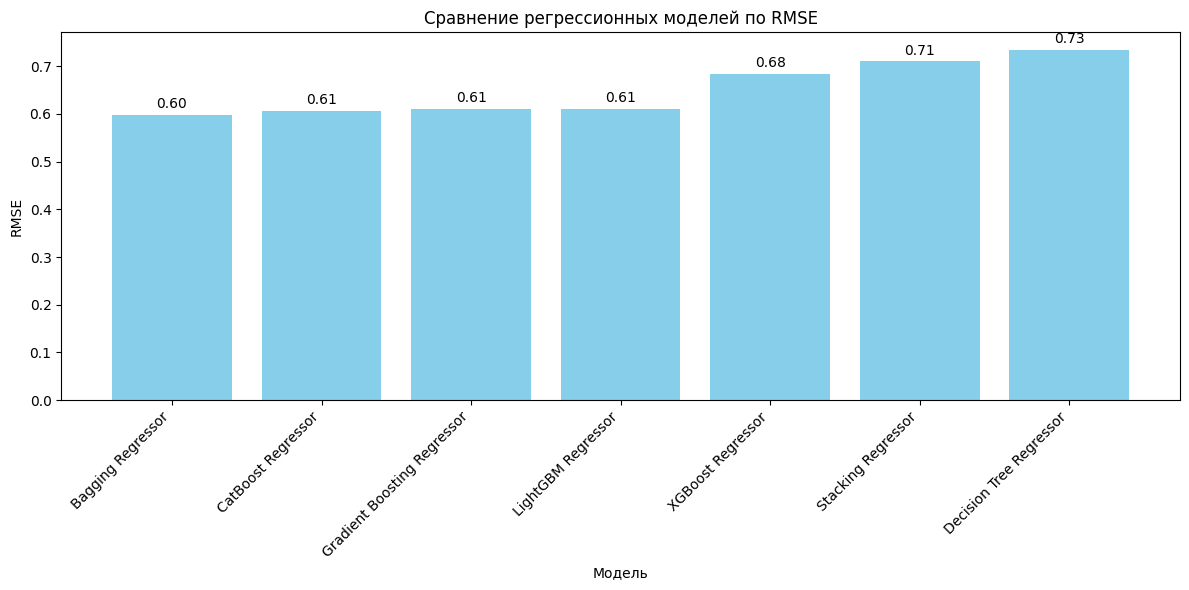

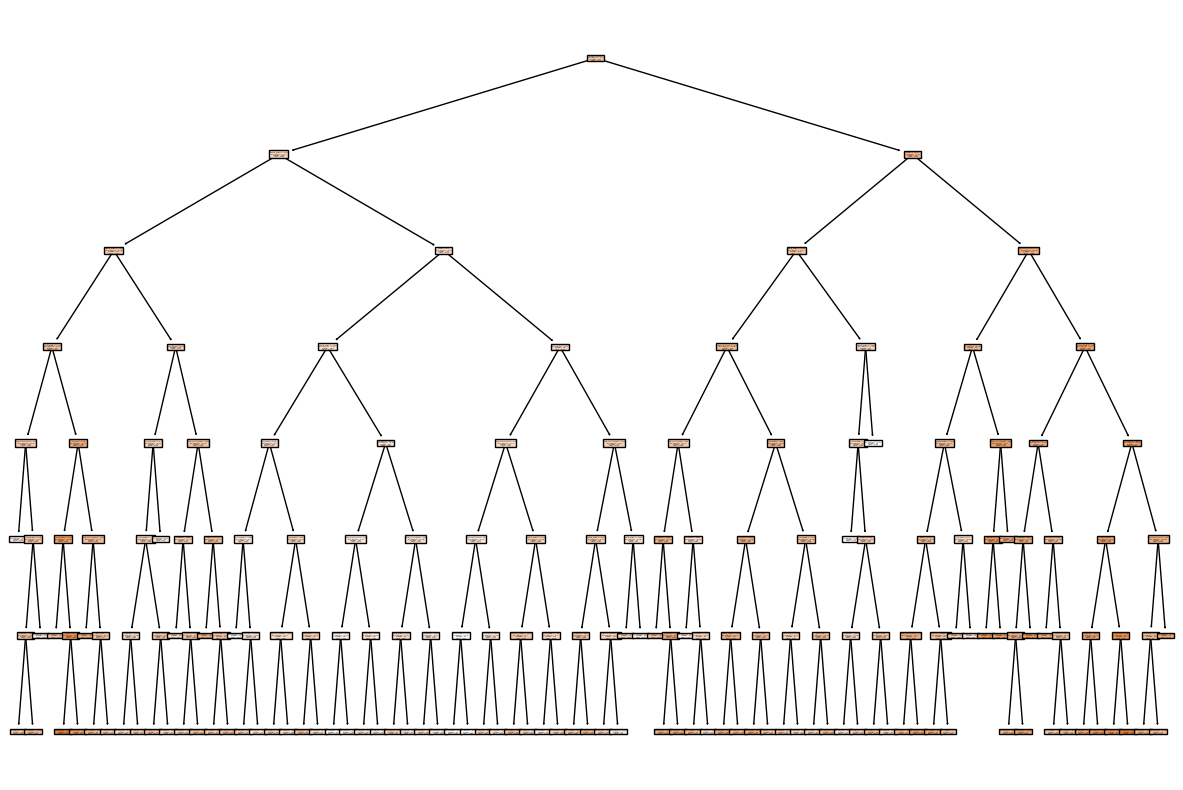

In [53]:
results = []
for model, name in zip(models, model_names):
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    results.append({'Model': name, 'MSE': mse, 'RMSE': rmse, 'R2': r2})

df = pd.DataFrame(results)
df = df.sort_values(by='RMSE')

print("Таблица сравнения:")
print(df)

plt.figure(figsize=(12, 6))
plt.bar(df['Model'], df['RMSE'], color='skyblue')
plt.xlabel('Модель')
plt.ylabel('RMSE')
plt.title('Сравнение регрессионных моделей по RMSE')
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(df['RMSE']):
    plt.text(i, v + 0.01 * max(df['RMSE']), f'{v:.2f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

fig = plt.figure(figsize=(15,10))
DT_plot = tree.plot_tree(reg, feature_names=X_train.columns, filled=True)